# Data Processing & Visualization with CRISP-DM, SEMMA and KDD
## Dataset: Automobile Market Analytics Dataset (Kaggle)

This notebook processes the **Automobile Market Analytics** dataset
(source: https://www.kaggle.com/datasets/deeplumiere/automobile-market-analytics-dataset)
end-to-end through three classic data-mining process frameworks: **CRISP-DM**, **SEMMA**, and **KDD**.
Each framework is applied independently to the same data so their approaches can be compared side by side.


## 0. Setup & data loading

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline


In [2]:
# Path to the downloaded Kaggle CSV (place it in the same folder as this notebook)
DATA_PATH = "automobile_dataset.csv"

df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
df_raw.head()


Shape: (5500, 18)

Columns: ['Make', 'Model', 'Year', 'Fuel_Type', 'Transmission', 'Engine_Size', 'Mileage', 'Horsepower', 'Torque', 'Owners', 'Accident_History', 'Service_History', 'Color', 'Body_Type', 'Drivetrain', 'Fuel_Efficiency', 'Location', 'Selling_Price']


,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
0,Mercedes-Benz,GLE,2024,Petrol,Automatic,2.3,100,186.0,196.0,1,0.0,NaN,Silver,SUV,AWD,30.0,IL,64140
1,Hyundai,Tucson,2008,Petrol,Automatic,2.3,387035,189.0,190.0,4,0.0,NaN,Blue,SUV,FWD,35.0,FL,500
2,Volkswagen,Golf,2021,Hybrid,NaN,1.9,46054,158.0,153.0,1,0.0,Partial Service,Gray,Hatchback,AWD,43.0,NY,16429
3,Chevrolet,Tahoe,2005,Petrol,NaN,2.2,141302,169.0,165.0,5,1.0,No Service,Blue,SUV,AWD,NaN,FL,2199
4,Toyota,Camry,2022,Petrol,Automatic,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792


### 0.5 — Shared helpers

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              mean_absolute_error, mean_squared_error, r2_score,
                              confusion_matrix, classification_report)

def eval_classifier(y_true, y_pred, label=""):
    print(f"--- {label} ---")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4))
    print("Recall   :", round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4))
    print("F1       :", round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4))

def eval_regressor(y_true, y_pred, label=""):
    print(f"--- {label} ---")
    print("MAE :", round(mean_absolute_error(y_true, y_pred), 3))
    print("RMSE:", round(mean_squared_error(y_true, y_pred) ** 0.5, 3))
    print("R2  :", round(r2_score(y_true, y_pred), 4))


## 1. Quick raw-data profile

In [4]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Make              5500 non-null   object 
 1   Model             5500 non-null   object 
 2   Year              5500 non-null   int64  
 3   Fuel_Type         5500 non-null   object 
 4   Transmission      4673 non-null   object 
 5   Engine_Size       4656 non-null   float64
 6   Mileage           5500 non-null   int64  
 7   Horsepower        4700 non-null   float64
 8   Torque            4701 non-null   float64
 9   Owners            5500 non-null   int64  
 10  Accident_History  4688 non-null   float64
 11  Service_History   4645 non-null   object 
 12  Color             4697 non-null   object 
 13  Body_Type         5500 non-null   object 
 14  Drivetrain        5500 non-null   object 
 15  Fuel_Efficiency   4706 non-null   float64
 16  Location          4718 non-null   object 


In [5]:
df_raw.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Make,5500,10,Hyundai,579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,5500,40,GLE,166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,5500.0,NaN,NaN,NaN,2014.494,5.789745,2005.0,2009.0,2014.0,2020.0,2024.0
Fuel_Type,5500,4,Petrol,4267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,4673,2,Automatic,4142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine_Size,4656.0,NaN,NaN,NaN,2.450623,0.843913,0.0,2.0,2.4,3.0,5.7
Mileage,5500.0,NaN,NaN,NaN,114529.481636,91858.943421,100.0,39112.0,96926.5,172757.5,536731.0
Horsepower,4700.0,NaN,NaN,NaN,198.236596,55.678165,97.0,160.0,187.0,231.0,434.0
Torque,4701.0,NaN,NaN,NaN,189.014678,56.631309,77.0,151.0,178.0,219.0,443.0
Owners,5500.0,NaN,NaN,NaN,2.464,1.280022,1.0,1.0,2.0,3.0,5.0


In [6]:
df_raw.isna().sum().sort_values(ascending=False).head(20)


Service_History     855
Engine_Size         844
Transmission        827
Accident_History    812
Color               803
Horsepower          800
Torque              799
Fuel_Efficiency     794
Location            782
Make                  0
Model                 0
Mileage               0
Fuel_Type             0
Year                  0
Owners                0
Body_Type             0
Drivetrain            0
Selling_Price         0
dtype: int64

In [7]:
# Quick look at categorical vs numeric columns
num_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
cat_cols = df_raw.select_dtypes(exclude=np.number).columns.tolist()
print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)


Numeric columns: ['Year', 'Engine_Size', 'Mileage', 'Horsepower', 'Torque', 'Owners', 'Accident_History', 'Fuel_Efficiency', 'Selling_Price']
Categorical columns: ['Make', 'Model', 'Fuel_Type', 'Transmission', 'Service_History', 'Color', 'Body_Type', 'Drivetrain', 'Location']


# 2. CRISP-DM
CRISP-DM has six phases: Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, Deployment.

### 2.1 Business Understanding

State the business question this analysis answers, e.g.:
> *Can we predict a vehicle's market price (or price category) from its listed attributes
> (make, year, mileage, engine size, fuel type, transmission, condition, etc.)?*

Adjust this to whatever target column your dataset actually contains (price, price range, or another target).


### 2.2 Data Understanding

Detected target column: Selling_Price


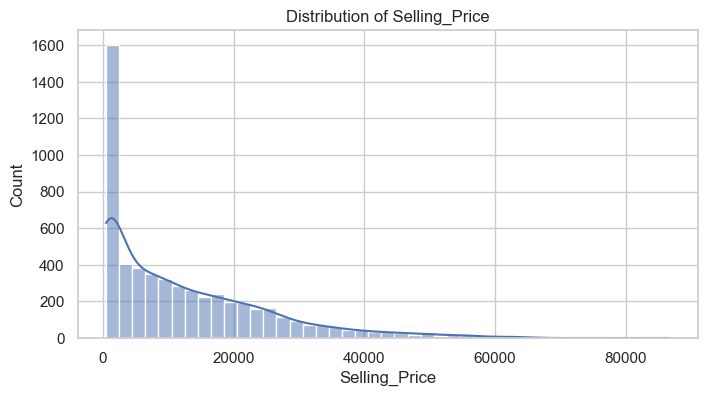

In [8]:
# Auto-detect the price/target column (falls back to manual override if needed)
price_candidates = [c for c in df_raw.columns if 'price' in c.lower()]
target_col = price_candidates[0] if price_candidates else None
print("Detected target column:", target_col)
# If this picked the wrong column, override manually, e.g.:
# target_col = "Price"
if target_col in df_raw.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df_raw[target_col].dropna(), kde=True)
    plt.title(f"Distribution of {target_col}")
    plt.show()


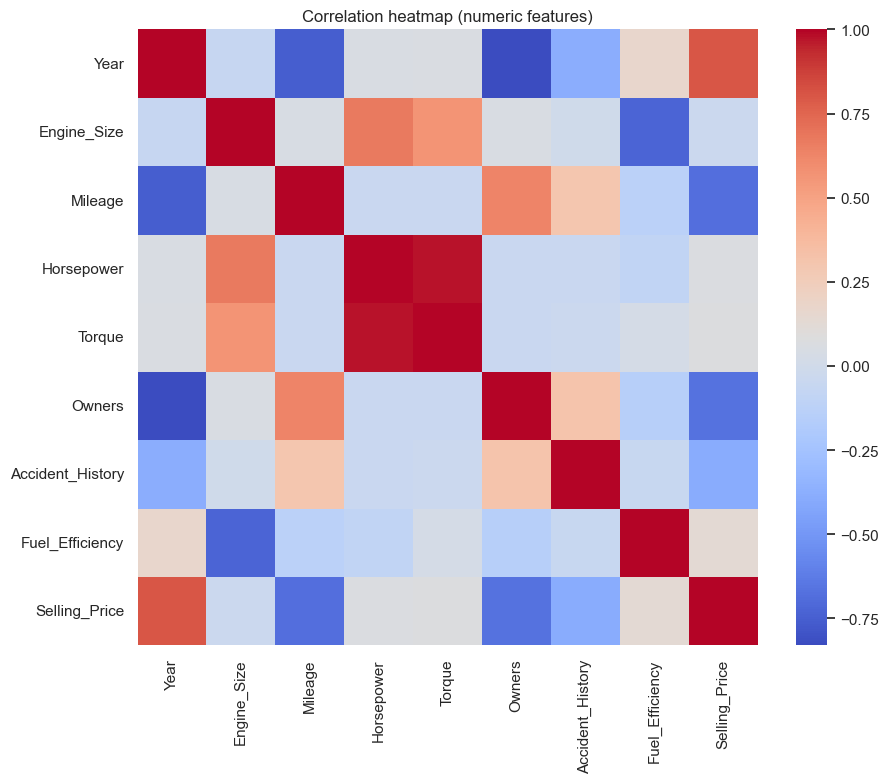

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df_raw[num_cols].corr(), annot=False, cmap="coolwarm")
plt.title("Correlation heatmap (numeric features)")
plt.show()


### 2.3 Data Preparation

In [10]:
df = df_raw.copy()

# Drop columns that are entirely empty or clearly unusable identifiers
df = df.dropna(axis=1, how='all')

# Simple imputation: median for numeric, mode for categorical
for c in df.select_dtypes(include=np.number).columns:
    df[c] = df[c].fillna(df[c].median())
for c in df.select_dtypes(exclude=np.number).columns:
    df[c] = df[c].fillna(df[c].mode().iloc[0] if not df[c].mode().empty else "Unknown")

# One-hot encode categoricals for modeling
df_model = pd.get_dummies(df, drop_first=True)
df_model.shape


(5500, 86)

### 2.4 Modeling

In [11]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Example: if target_col is numeric, do regression; if categorical, do classification.
# Adjust this block once you know the real target column.
if target_col in df_model.columns:
    X = df_model.drop(columns=[target_col])
    y = df_model[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(random_state=42, n_estimators=300)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)


### 2.5 Evaluation

In [14]:
if target_col in df_model.columns:
    eval_regressor(y_test, preds, label="CRISP-DM RandomForest")


--- CRISP-DM RandomForest ---
MAE : 1361.728
RMSE: 2139.959
R2  : 0.9709


### 2.6 Deployment

Describe how this model/insight would be used in practice — e.g. embedded in a pricing
tool for a used-car marketplace, or a dashboard flagging under/over-priced listings.


# 3. SEMMA
Sample → Explore → Modify → Model → Assess (developed by SAS).

**Sample**

In [ ]:
df_sample = df.sample(frac=0.8, random_state=42) if len(df) > 5000 else df.copy()
df_sample.shape


**Explore**

In [ ]:
sns.pairplot(df_sample[num_cols[:4]].dropna())
plt.show()


**Modify**

In [ ]:
from sklearn.preprocessing import StandardScaler

df_semma = pd.get_dummies(df_sample, drop_first=True)
scaler = StandardScaler()
scaled_num_cols = [c for c in num_cols if c in df_semma.columns]
df_semma[scaled_num_cols] = scaler.fit_transform(df_semma[scaled_num_cols])


**Model**

In [ ]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import make_pipeline

# Swap for LogisticRegression + classification metrics if your target is categorical
if target_col in df_semma.columns:
    X = df_semma.drop(columns=[target_col])
    y = df_semma[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    lin_model = LinearRegression()
    lin_model.fit(X_train, y_train)
    semma_preds = lin_model.predict(X_test)


**Assess**

In [ ]:
if target_col in df_semma.columns:
    eval_regressor(y_test, semma_preds, label="SEMMA LinearRegression")


# 4. KDD
Selection → Preprocessing → Transformation → Data Mining → Interpretation/Evaluation.

**Selection**

In [ ]:
kdd_cols = num_cols  # start with numeric columns; narrow down as needed
df_kdd = df[kdd_cols].copy()


**Preprocessing**

In [ ]:
df_kdd = df_kdd.fillna(df_kdd.median())


**Transformation**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler2 = StandardScaler()
df_kdd_scaled = pd.DataFrame(scaler2.fit_transform(df_kdd), columns=df_kdd.columns)


**Data Mining** (unsupervised: clustering market segments)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_kdd_scaled)
df_kdd["cluster"] = clusters
df_kdd["cluster"].value_counts()


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
# Optional supervised pass, e.g. predicting a categorical target such as condition or fuel type


**Interpretation / Evaluation**

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_kdd.iloc[:,0], y=df_kdd.iloc[:,1], hue=df_kdd["cluster"], palette="tab10")
plt.title("KMeans clusters (first two numeric features)")
plt.show()


# 5. Final comparison of the three frameworks

| Framework | Focus | Strength | Best for |
|---|---|---|---|
| CRISP-DM | Business-driven, full lifecycle | Stakeholder alignment, deployment step | Complex, business-facing projects |
| SEMMA | SAS analytic workflow | Fast, iteration-friendly | Prototyping predictive models |
| KDD | Knowledge discovery, research-oriented | Rigorous preprocessing, pattern discovery | Exploratory / unsupervised analysis |


### 5.5 Takeaways

Summarize, in your own words, what each framework revealed about the automobile market data —
e.g. which features drove price the most, what the clusters represent (budget/economy/luxury segments),
and which framework felt most natural for this dataset.
